# Phase 2 — Particle Filter (SIR)

SIR particle filter with Student-t observation likelihood,
compared against the Kalman baseline from Phase 1.

In [1]:
import sys, pathlib, json
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))

import numpy as np
import matplotlib.pyplot as plt
import librosa, librosa.display
from audio_io import (
    load_mono_16k, loop_to_length, mix_at_snr,
    peak_normalize, save_wav, TARGET_SR
)
from kalman import (
    fit_ar_per_frame, kalman_filter_signal, estimate_R, compute_snr
)
from particle import particle_filter_signal, estimate_t_params

AUDIO_DIR = pathlib.Path.cwd().parent / 'Audios'
OUT_DIR   = pathlib.Path.cwd().parent / 'data' / 'synth'
SNRS      = [-5, 0, 5, 10, 15]

doctor  = load_mono_16k(AUDIO_DIR / 'Doctor.wav')
patient = load_mono_16k(AUDIO_DIR / 'Patient.wav')
noise_raw = load_mono_16k(AUDIO_DIR / 'Background_Noise.wav')
min_len = min(len(doctor), len(patient))
clean_full = peak_normalize(0.5*(doctor[:min_len]+patient[:min_len]))
noise_full = loop_to_length(noise_raw, min_len)

seg_start = 30 * TARGET_SR
seg_dur   = 60 * TARGET_SR
clean = clean_full[seg_start:seg_start+seg_dur]
noise = noise_full[seg_start:seg_start+seg_dur]

/Users/miguel/Documents/PoD/Information-Theory-Inference/Project_Miguel/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load pre-computed results

In [2]:
with open(OUT_DIR / 'filter_results.json') as f:
    results = json.load(f)

for r in results:
    print(f"SNR={r['snr_in']:+3d} | KF={r['kf_out']:+.2f} (gain={r['kf_gain']:+.2f}) | "
          f"PF={r['pf_out']:+.2f} (gain={r['pf_gain']:+.2f}) | df={r['df']}")

SNR= -5 | KF=-0.65 (gain=+4.35) | PF=-0.20 (gain=+4.80) | df=4.2
SNR= +0 | KF=+3.41 (gain=+3.41) | PF=+3.78 (gain=+3.78) | df=4.2
SNR= +5 | KF=+7.68 (gain=+2.68) | PF=+7.90 (gain=+2.90) | df=4.2
SNR=+10 | KF=+12.13 (gain=+2.13) | PF=+12.17 (gain=+2.17) | df=4.2
SNR=+15 | KF=+16.72 (gain=+1.72) | PF=+16.07 (gain=+1.07) | df=4.2


## 2. KF vs PF comparison plot

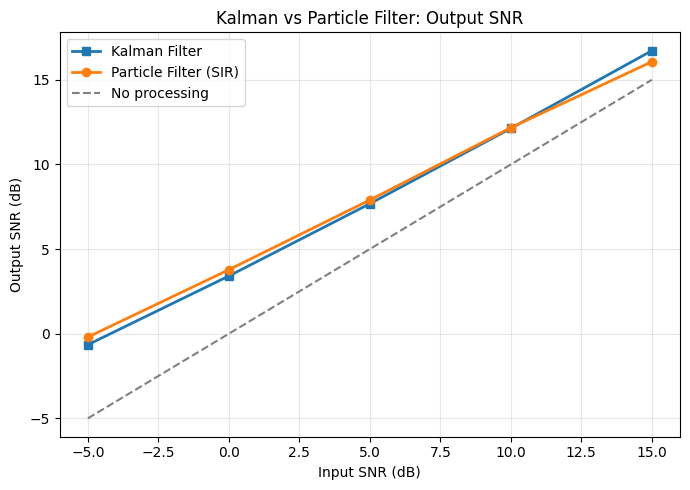

In [3]:
snrs_in = [r['snr_in'] for r in results]
kf_out  = [r['kf_out'] for r in results]
pf_out  = [r['pf_out'] for r in results]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(snrs_in, kf_out, 's-', label='Kalman Filter', linewidth=2)
ax.plot(snrs_in, pf_out, 'o-', label='Particle Filter (SIR)', linewidth=2)
ax.plot(snrs_in, snrs_in, '--', color='gray', label='No processing')
ax.set_xlabel('Input SNR (dB)')
ax.set_ylabel('Output SNR (dB)')
ax.set_title('Kalman vs Particle Filter: Output SNR')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(OUT_DIR / 'kf_vs_pf_snr.png'), dpi=150)
plt.show()

## 3. Side-by-side spectrograms at 0 dB

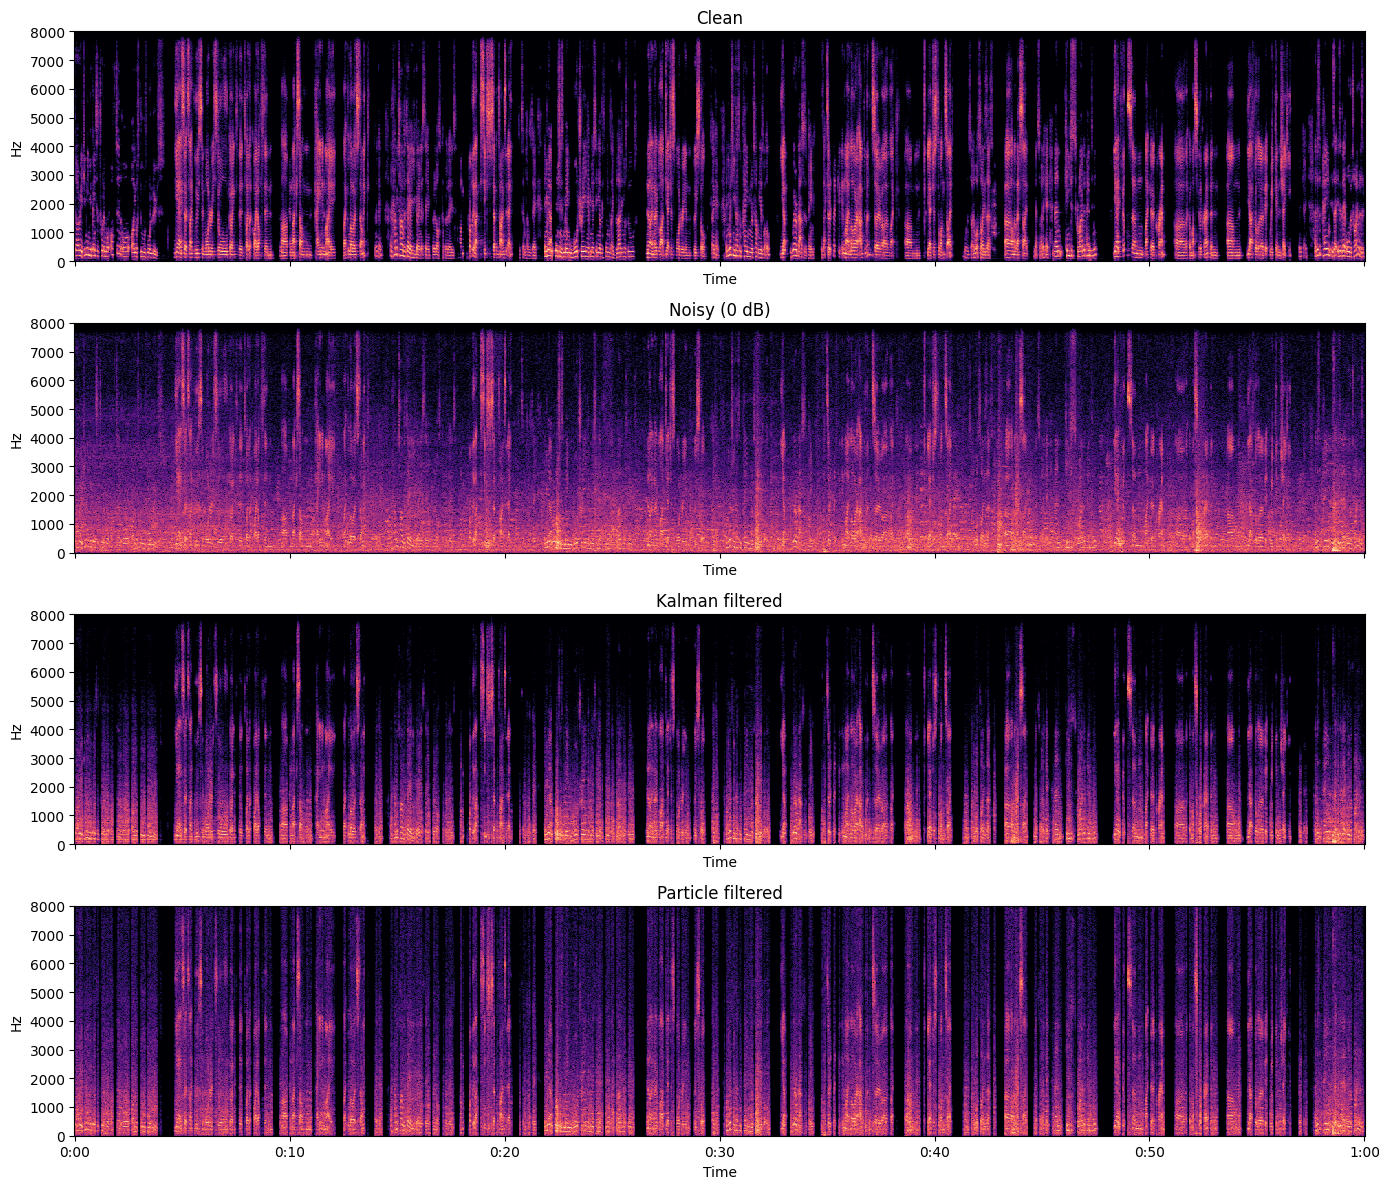

In [4]:
noisy_0 = mix_at_snr(clean, noise, 0.0)
ar_frames = fit_ar_per_frame(clean, order=10)
R = estimate_R(clean, noisy_0)
x_kf = kalman_filter_signal(noisy_0, ar_frames, R, order=10)

actual_n = noisy_0 - clean
df, scale = estimate_t_params(actual_n)
x_pf = particle_filter_signal(noisy_0, ar_frames, df=df, obs_scale=scale, n_particles=200)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
for ax, sig, title in zip(axes,
    [clean, noisy_0, x_kf, x_pf],
    ['Clean', 'Noisy (0 dB)', 'Kalman filtered', 'Particle filtered']):
    S = librosa.amplitude_to_db(np.abs(librosa.stft(sig)), ref=np.max)
    librosa.display.specshow(S, sr=TARGET_SR, x_axis='time', y_axis='hz', ax=ax)
    ax.set_title(title)
    ax.set_ylim(0, 8000)
plt.tight_layout()
plt.savefig(str(OUT_DIR / 'pf_spectrograms.png'), dpi=150)
plt.show()

## 4. Waveform zoom-in (impulsive segment)

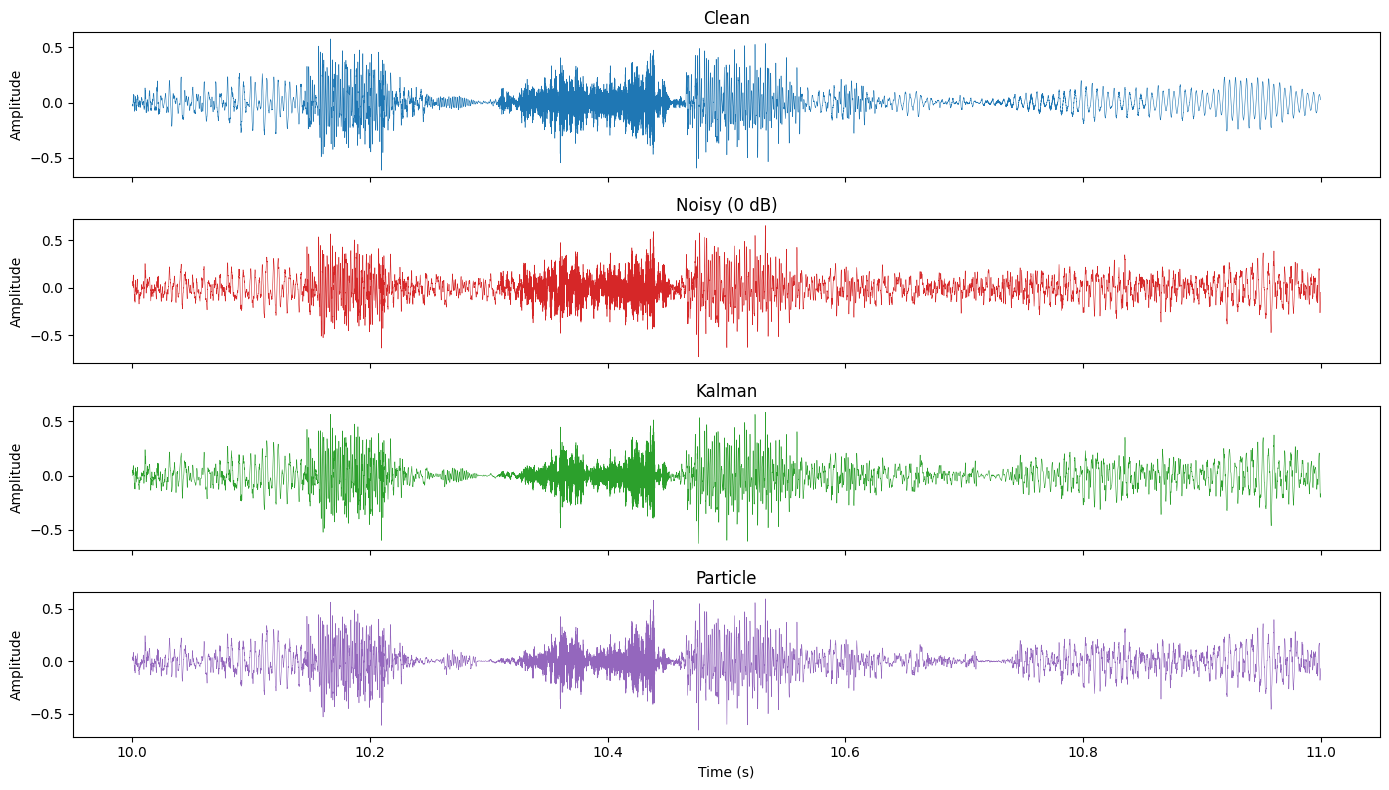

In [ ]:
t0_s, dur_s = 30, 5
t0_samp = t0_s * TARGET_SR
dur_samp = dur_s * TARGET_SR
t = np.arange(dur_samp) / TARGET_SR + t0_s

fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)
for ax, sig, title, color in zip(axes,
    [clean, noisy_0, x_kf, x_pf],
    ['Clean', 'Noisy (0 dB)', 'Kalman', 'Particle'],
    ['tab:blue', 'tab:red', 'tab:green', 'tab:purple']):
    ax.plot(t, sig[t0_samp:t0_samp+dur_samp], linewidth=0.4, color=color)
    ax.set_title(title)
    ax.set_ylabel('Amplitude')
axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig(str(OUT_DIR / 'pf_waveforms_zoom.png'), dpi=150)
plt.show()